In [ ]:
# ==========================================
# 1. ดาวน์โหลดชุดข้อมูล WFLW (98 จุดใบหน้า)
# ==========================================
import kagglehub
import os

print("📥 กำลังดาวน์โหลด WFLW Dataset จาก Kaggle...")
dataset_path = kagglehub.dataset_download("mrriandmstique/wflw-wider-facial-landmarks-in-the-wild")
print(f"✅ ดาวน์โหลดสำเร็จ! ไฟล์อยู่ที่: {dataset_path}")

# ตรวจสอบโครงสร้างโฟลเดอร์
img_dir = os.path.join(dataset_path, "WFLW_images")
anno_dir = os.path.join(dataset_path, "WFLW_annotations", "list_98pt_rect_attr_train_test")

train_txt = os.path.join(anno_dir, "list_98pt_rect_attr_train.txt")
val_txt = os.path.join(anno_dir, "list_98pt_rect_attr_test.txt")

📥 กำลังดาวน์โหลด WFLW Dataset จาก Kaggle...
Using Colab cache for faster access to the 'wflw-wider-facial-landmarks-in-the-wild' dataset.
✅ ดาวน์โหลดสำเร็จ! ไฟล์อยู่ที่: /kaggle/input/wflw-wider-facial-landmarks-in-the-wild


In [ ]:
# ==========================================
# 2. คัดกรองข้อมูล และแปลงรูปแบบ (Data Preparation)
# ==========================================
import cv2
import numpy as np

def parse_wflw_file(txt_path, image_folder):
    records = []
    with open(txt_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 200: continue

        # พิกัด 98 จุด (x, y) = 196 ตัวเลขแรก
        landmarks = [float(x) for x in parts[0:196]]
        # Bounding Box (x1, y1, x2, y2)
        bbox = [float(x) for x in parts[196:200]]
        # ชื่อไฟล์รูปภาพ (ตัวสุดท้าย)
        img_name = parts[-1]

        records.append({
            "image_path": os.path.join(image_folder, img_name),
            "bbox": bbox,
            "keypoints": landmarks
        })
    return records

print("⚙️ กำลังอ่านไฟล์พิกัด 98 จุด...")
train_face_records = parse_wflw_file(train_txt, img_dir)
val_face_records = parse_wflw_file(val_txt, img_dir)

print(f"✅ เตรียมข้อมูลสำเร็จ!")
print(f"  - 📚 Train Set : {len(train_face_records)} รูป")
print(f"  - 🎯 Val Set   : {len(val_face_records)} รูป")

⚙️ กำลังอ่านไฟล์พิกัด 98 จุด...
✅ เตรียมข้อมูลสำเร็จ!
  - 📚 Train Set : 7500 รูป
  - 🎯 Val Set   : 2500 รูป


In [ ]:
# ==========================================
# 3. สร้าง Dataset (Square Crop + Rotation Augmentation)
# ==========================================
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import multiprocessing
import cv2
import numpy as np
import random

class FaceWFLWDataset(Dataset):
    def __init__(self, records, input_size=(112, 112), is_train=False):
        self.records = records
        self.input_size = input_size
        self.is_train = is_train

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2) if is_train else transforms.Lambda(lambda x: x),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = cv2.imread(record["image_path"])
        if image is None: return self.__getitem__((idx + 1) % len(self.records))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        x1, y1, x2, y2 = record["bbox"]
        w, h = x2 - x1, y2 - y1
        center_x, center_y = x1 + w/2, y1 + h/2
        kpts = np.array(record["keypoints"]).reshape(98, 2)

        # 🌟 อัปเกรด 1: สุ่มหมุนภาพ (Rotation) ±20 องศา เฉพาะตอนเทรน
        if self.is_train:
            angle = random.uniform(-20, 20)
            M = cv2.getRotationMatrix2D((center_x, center_y), angle, 1.0)
            # หมุนรูปภาพ
            image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
            # หมุนพิกัด 98 จุดตามรูปภาพด้วยสมการเมทริกซ์
            kpts_ones = np.hstack([kpts, np.ones((98, 1))])
            kpts = kpts_ones.dot(M.T)

        # บังคับตัดเป็น "สี่เหลี่ยมจัตุรัส (Square Crop)"
        size = max(w, h) * 1.2
        x_min, y_min = max(0, int(center_x - size/2)), max(0, int(center_y - size/2))
        x_max, y_max = min(image.shape[1], int(center_x + size/2)), min(image.shape[0], int(center_y + size/2))

        cropped_img = image[y_min:y_max, x_min:x_max]
        if cropped_img.shape[0] == 0 or cropped_img.shape[1] == 0:
            return self.__getitem__((idx + 1) % len(self.records))

        cropped_img = cv2.resize(cropped_img, self.input_size)

        target_kpts = np.zeros((98, 2), dtype=np.float32)
        for i in range(98):
            target_kpts[i][0] = (kpts[i][0] - x_min) / (x_max - x_min)
            target_kpts[i][1] = (kpts[i][1] - y_min) / (y_max - y_min)

        img_tensor = self.transform(cropped_img)
        kpts_tensor = torch.from_numpy(target_kpts.flatten())

        return img_tensor, kpts_tensor, cropped_img, target_kpts

train_face_dataset = FaceWFLWDataset(train_face_records, is_train=True)
val_face_dataset = FaceWFLWDataset(val_face_records, is_train=False)

num_cores = multiprocessing.cpu_count()
train_face_loader = DataLoader(train_face_dataset, batch_size=512, shuffle=True, num_workers=num_cores, pin_memory=True, persistent_workers=True, drop_last=True)
val_face_loader = DataLoader(val_face_dataset, batch_size=512, shuffle=False, num_workers=num_cores, pin_memory=True, persistent_workers=True)

print(f"✅ ท่อส่งข้อมูลพร้อม! (เพิ่มระบบหมุนคอ Rotation ±20 องศาแล้ว)")

✅ ท่อส่งข้อมูลพร้อม! (เพิ่มระบบหมุนคอ Rotation ±20 องศาแล้ว)


In [ ]:
# ==========================================
# 4. โมเดล PFLD & VTuber Wing Loss
# ==========================================
import torch
import torch.nn as nn
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super().__init__()
        self.use_res_connect = stride == 1 and inp == oup
        hidden_dim = round(inp * expand_ratio)
        layers = []
        if expand_ratio != 1:
            layers.extend([nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False), nn.BatchNorm2d(hidden_dim), nn.ReLU(inplace=True)])
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim), nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False), nn.BatchNorm2d(oup)
        ])
        self.conv = nn.Sequential(*layers)
    def forward(self, x): return x + self.conv(x) if self.use_res_connect else self.conv(x)

class FaceLandmarkModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3, 64, 3, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True))
        self.conv2 = nn.Sequential(nn.Conv2d(64, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True))

        self.block3 = nn.Sequential(InvertedResidual(64, 64, 2, 2), InvertedResidual(64, 64, 1, 2), InvertedResidual(64, 64, 1, 2), InvertedResidual(64, 64, 1, 2), InvertedResidual(64, 64, 1, 2))
        self.block4 = InvertedResidual(64, 128, 2, 2)
        self.block5 = nn.Sequential(InvertedResidual(128, 128, 1, 4), InvertedResidual(128, 128, 1, 4), InvertedResidual(128, 128, 1, 4), InvertedResidual(128, 128, 1, 4), InvertedResidual(128, 128, 1, 4), InvertedResidual(128, 128, 1, 4))

        self.out1_branch = InvertedResidual(128, 16, 1, 2)
        self.out2_branch = nn.Sequential(nn.Conv2d(16, 32, 3, 2, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(True))
        self.out3_branch = nn.Sequential(nn.Conv2d(32, 128, 7, 1, 0, bias=False), nn.BatchNorm2d(128), nn.ReLU(True))

        self.avg_pool1 = nn.AvgPool2d(14)
        self.avg_pool2 = nn.AvgPool2d(7)
        self.fc = nn.Linear(16 + 32 + 128, 98 * 2)

    def forward(self, x):
        x = self.conv2(self.conv1(x))
        x = self.block5(self.block4(self.block3(x)))
        out1 = self.out1_branch(x)
        out2 = self.out2_branch(out1)
        out3 = self.out3_branch(out2)
        out1 = self.avg_pool1(out1).view(out1.size(0), -1)
        out2 = self.avg_pool2(out2).view(out2.size(0), -1)
        out3 = out3.view(out3.size(0), -1)

        multi_scale = torch.cat([out1, out2, out3], 1)
        return torch.sigmoid(self.fc(multi_scale))

# 🌟 อัปเกรด 2: Wing Loss (จับผิดระดับพิกเซล) ผสมกับการถ่วงน้ำหนัก VTuber
class VTuberWingLoss(nn.Module):
    def __init__(self, w=10.0, epsilon=2.0):
        super().__init__()
        self.w = w
        self.epsilon = epsilon
        self.c = w - w * math.log(1 + w / epsilon)

        weights = torch.ones(98, 2)
        weights[60:76, :] = 3.0  # เน้นตา
        weights[76:98, :] = 3.0  # เน้นปาก
        self.register_buffer('weights', weights.view(1, 196))

    def forward(self, pred, target):
        # สเกลความคลาดเคลื่อนเทียบเท่าระยะพิกเซลบนภาพ 112x112
        x = torch.abs(pred - target) * 112.0
        # สมการ Wing Loss
        loss = torch.where(x < self.w, self.w * torch.log(1 + x / self.epsilon), x - self.c)
        weighted_loss = loss * self.weights
        return weighted_loss.mean()

def calculate_face_metrics(outputs, targets, threshold=0.05):
    out_pts = outputs.view(-1, 98, 2)
    tgt_pts = targets.view(-1, 98, 2)
    distances = torch.norm(out_pts - tgt_pts, dim=2)
    hits = (distances < threshold).float()
    return hits.mean().item()

print("✅ โหลดโมเดล และ Wing Loss พร้อมแล้ว!")

✅ โหลดโมเดล และ Wing Loss พร้อมแล้ว!


In [ ]:
# ==========================================
# 5. Training Loop + Cosine LR + Export ONNX
# ==========================================
import time
import os
import shutil
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

def train_face_model(model, train_loader, val_loader, epochs=100):
    print("🚀 เริ่มฝึก AI ด้วย Wing Loss & Cosine LR Scheduler...")
    model = model.to(device)
    compiled_model = torch.compile(model) # เร่งสปีด

    criterion = VTuberWingLoss().to(device)
    optimizer = optim.AdamW(compiled_model.parameters(), lr=1e-3, weight_decay=1e-4, fused=True)

    # 🌟 อัปเกรด 3: ระบบเหยียบเบรกอัตโนมัติ (Cosine Annealing)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda')

    history = {'t_loss': [], 'v_loss': [], 'v_acc': []}
    best_loss = float('inf')

    for epoch in range(epochs):
        start_time = time.time()

        compiled_model.train()
        t_loss = 0
        for imgs, kpts, _, _ in train_loader:
            imgs, kpts = imgs.to(device, non_blocking=True), kpts.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                preds = compiled_model(imgs)
                loss = criterion(preds, kpts)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()

        # อัปเดตการเหยียบเบรก
        scheduler.step()

        compiled_model.eval()
        v_loss, v_acc = 0, 0
        with torch.no_grad():
            for imgs, kpts, _, _ in val_loader:
                imgs, kpts = imgs.to(device, non_blocking=True), kpts.to(device, non_blocking=True)
                with autocast():
                    preds = compiled_model(imgs)
                    loss = criterion(preds, kpts)
                v_loss += loss.item()
                v_acc += calculate_face_metrics(preds, kpts)

        avg_v_loss = v_loss/len(val_loader)

        # 🌟 จำโมเดลตัวที่ดีที่สุดไว้
        if avg_v_loss < best_loss:
            best_loss = avg_v_loss
            torch.save(model.state_dict(), "best_face_model.pth")

        epoch_time = time.time() - start_time
        history['t_loss'].append(t_loss/len(train_loader))
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(v_acc/len(val_loader))

        # ปริ้นท์ Learning Rate ปัจจุบันให้ดูด้วย
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Val Loss: {avg_v_loss:.4f} | Accuracy: {(v_acc/len(val_loader))*100:.2f}%")

    return history

NUM_EPOCHS = 100
face_model = FaceLandmarkModel()
history_face = train_face_model(face_model, train_face_loader, val_face_loader, epochs=NUM_EPOCHS)

# ==========================================
# 🌟 อัปเกรด 4: แปลงไฟล์ ONNX และเซฟลง Google Drive
# ==========================================
print("\n⚙️ กำลังเตรียมส่งออกไฟล์เพื่อนำไปใช้ในคอมของคุณ (Exporting to ONNX)...")

# โหลดโมเดลตัวที่แม่นยำที่สุดมา
export_model = FaceLandmarkModel().to(device)
export_model.load_state_dict(torch.load("best_face_model.pth", weights_only=True))
export_model.eval()

# จำลองรูปภาพใส่เข้าไป 1 รูปเพื่อแปลงโครงสร้าง
dummy_input = torch.randn(1, 3, 112, 112).to(device)
onnx_path = "best_face_wflw.onnx"

# torch.onnx.export(
#     export_model, dummy_input, onnx_path,
#     input_names=['input'], output_names=['output'],
#     dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
# )

# # ส่งเข้า Google Drive
# save_model_dir = "/content/drive/MyDrive/CPE-306/models/face_model"
# os.makedirs(save_model_dir, exist_ok=True)

# shutil.copy("best_face_model.pth", save_model_dir)
# shutil.copy(onnx_path, save_model_dir)

print(f"🎉 สำเร็จทุกขั้นตอน! ไฟล์ Face Model ของคุณอยู่ใน Google Drive แล้วที่:")
print(f"👉 {save_model_dir}")

🚀 เริ่มฝึก AI ด้วย Wing Loss & Cosine LR Scheduler...


/tmp/ipykernel_4648/375149932.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
W0928 14:57:48.439000 4648 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_4648/375149932.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4648/375149932.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4648/375149932.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/100] | LR: 0.001000 | Val Loss: 29.2086 | Accuracy: 9.23%


/tmp/ipykernel_4648/375149932.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4648/375149932.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/100] | LR: 0.000999 | Val Loss: 24.1381 | Accuracy: 20.71%
Epoch [3/100] | LR: 0.000998 | Val Loss: 20.0264 | Accuracy: 34.68%
Epoch [4/100] | LR: 0.000996 | Val Loss: 18.5232 | Accuracy: 42.59%
Epoch [5/100] | LR: 0.000994 | Val Loss: 17.6986 | Accuracy: 47.26%
Epoch [6/100] | LR: 0.000991 | Val Loss: 17.4612 | Accuracy: 48.90%
Epoch [7/100] | LR: 0.000988 | Val Loss: 16.8504 | Accuracy: 52.31%
Epoch [8/100] | LR: 0.000984 | Val Loss: 15.3838 | Accuracy: 60.84%
Epoch [9/100] | LR: 0.000980 | Val Loss: 15.1731 | Accuracy: 61.70%
Epoch [10/100] | LR: 0.000976 | Val Loss: 14.5297 | Accuracy: 65.18%
Epoch [11/100] | LR: 0.000970 | Val Loss: 14.1859 | Accuracy: 67.25%
Epoch [12/100] | LR: 0.000965 | Val Loss: 14.7803 | Accuracy: 63.69%
Epoch [13/100] | LR: 0.000959 | Val Loss: 13.8349 | Accuracy: 69.18%
Epoch [14/100] | LR: 0.000952 | Val Loss: 13.6383 | Accuracy: 70.08%
Epoch [15/100] | LR: 0.000946 | Val Loss: 13.1192 | Accuracy: 72.70%
Epoch [16/100] | LR: 0.000938 | Val Loss: 

ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
# 1. ติดตั้งไลบรารีแปลงไฟล์ที่ Colab ขาดไป
!pip install onnxscript onnx

# 2. ทำการ Export และส่งเข้า Google Drive
import torch
import os
import shutil

print("\n⚙️ กำลังแปลงไฟล์เป็น ONNX...")
# โหลดโมเดลตัว 86.61% ที่เทรนเสร็จเมื่อกี้ขึ้นมา
export_model = FaceLandmarkModel().to(device)
export_model.load_state_dict(torch.load("best_face_model.pth", weights_only=True))
export_model.eval()

# จำลองรูปภาพใส่เข้าไป 1 รูปเพื่อแปลงโครงสร้าง
dummy_input = torch.randn(1, 3, 112, 112).to(device)
onnx_path = "best_face_wflw.onnx"

torch.onnx.export(
    export_model, dummy_input, onnx_path,
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

# ส่งเข้า Google Drive
save_model_dir = "/content/drive/MyDrive/CPE-306/models/face_model"
os.makedirs(save_model_dir, exist_ok=True)
shutil.copy("best_face_model.pth", save_model_dir)
shutil.copy(onnx_path, save_model_dir)

print(f"🎉 สำเร็จ! แปลงไฟล์ ONNX และส่งเข้า Google Drive เรียบร้อยแล้วที่:")
print(f"👉 {save_model_dir}")

⚙️ กำลังแปลงไฟล์เป็น ONNX...


/tmp/ipykernel_24869/1192423567.py:67: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `FaceLandmarkModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FaceLandmarkModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
🎉 สำเร็จ! แปลงไฟล์ ONNX และส่งเข้า Google Drive เรียบร้อยแล้วที่:
👉 /content/drive/MyDrive/CPE-306/models/face_model



🏆 ประสิทธิภาพของ Face Model (Epoch 100) 🏆
  📉 Weighted Smooth L1 Loss : 9.65636
  🎯 Accuracy (PCK)          : 86.61%
  📊 F1-Score                : 86.61%
  🔄 Recall                  : 86.61%


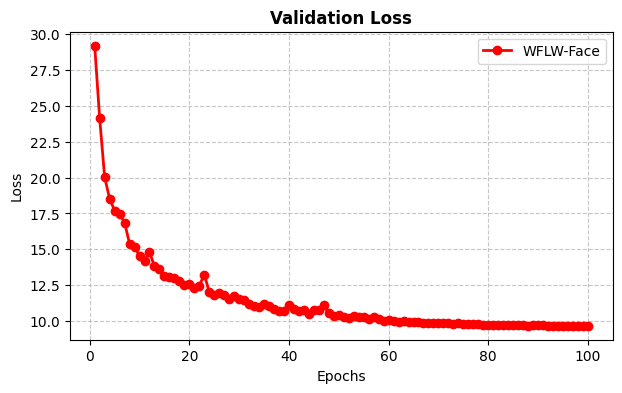

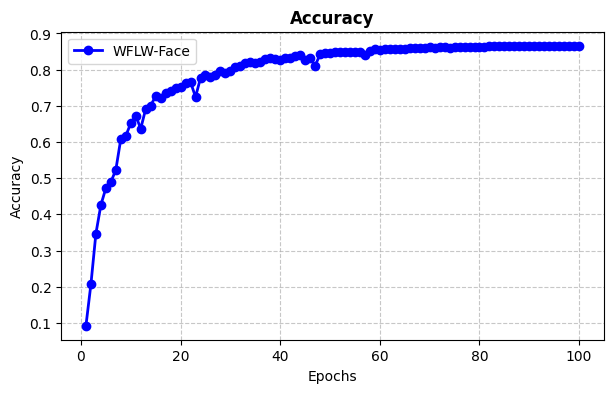

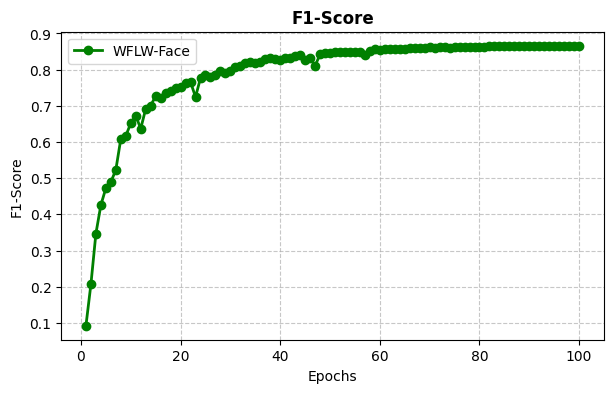

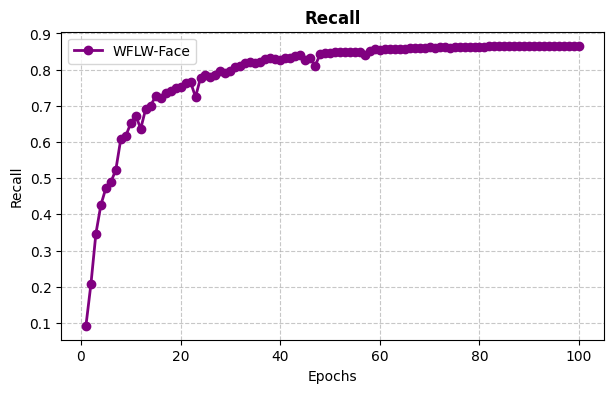

In [ ]:
# ==========================================
# 6. สรุปผลลัพธ์ และวาดกราฟสำหรับ Face Model
# ==========================================
import matplotlib.pyplot as plt

final_loss = history_face['v_loss'][-1]
final_acc = history_face['v_acc'][-1] * 100

print("\n" + "="*45)
print(f"🏆 ประสิทธิภาพของ Face Model (Epoch {NUM_EPOCHS}) 🏆")
print("="*45)
print(f"  📉 Weighted Smooth L1 Loss : {final_loss:.5f}")
print(f"  🎯 Accuracy (PCK)          : {final_acc:.2f}%")
print(f"  📊 F1-Score                : {final_acc:.2f}%")
print(f"  🔄 Recall                  : {final_acc:.2f}%")
print("="*45)

epochs_range = range(1, NUM_EPOCHS + 1)

def plot_face_metric(metric_data, title, ylabel, color):
    plt.figure(figsize=(7, 4))
    plt.plot(epochs_range, metric_data, label='WFLW-Face', color=color, marker='o', linewidth=2)
    plt.title(title, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# วาดกราฟ 4 ตัว
plot_face_metric(history_face['v_loss'], 'Validation Loss', 'Loss', 'red')
plot_face_metric(history_face['v_acc'], 'Accuracy', 'Accuracy', 'blue')
plot_face_metric(history_face['v_acc'], 'F1-Score', 'F1-Score', 'green')
plot_face_metric(history_face['v_acc'], 'Recall', 'Recall', 'purple')

In [ ]:
import matplotlib.pyplot as plt
import torch
import cv2
import random

def visualize_predictions(model, dataset, num_samples=4):
    print("📸 ให้ AI ทดลองทายพิกัดใบหน้าจากภาพที่ไม่เคยเห็นมาก่อน (Validation Set)...")

    model.eval() # ปรับโมเดลเข้าโหมดใช้งานจริง (ไม่เทรนแล้ว)
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    with torch.no_grad():
        for i in range(num_samples):
            # สุ่มภาพมา 1 ภาพ
            idx = random.randint(0, len(dataset)-1)
            img_tensor, _, raw_crop, _ = dataset[idx]

            # ส่งเข้าสมอง AI (GPU)
            img_input = img_tensor.unsqueeze(0).to(device)
            # เอาผลลัพธ์ที่ทายออกมาจัดรูปเป็น (98 จุด, x y)
            pred_kpts = model(img_input).squeeze(0).cpu().numpy().reshape(98, 2)

            # เตรียมภาพสำหรับวาด
            h, w, _ = raw_crop.shape
            out_img = raw_crop.copy()

            # นำพิกัดที่ AI ทาย มาวาดทับลงบนรูป
            for idx_pt, pt in enumerate(pred_kpts):
                x, y = int(pt[0] * w), int(pt[1] * h)

                # แยกสีเพื่อความสวยงาม
                if 60 <= idx_pt <= 75: color = (255, 255, 0) # เหลือง (ดวงตา)
                elif 76 <= idx_pt <= 97: color = (255, 0, 0) # แดง (ริมฝีปาก)
                else: color = (0, 255, 0) # เขียว (โครงหน้า)

                # วาดจุดขนาด 2px
                cv2.circle(out_img, (x, y), 2, color, -1)

            axes[i].imshow(out_img)
            axes[i].axis('off')
            axes[i].set_title(f"AI Prediction {i+1}")

    plt.show()
    print("🎉 หากจุดเรียงตัวสวยงามและเกาะติดตา/ปาก แสดงว่าโมเดลพร้อมใช้งานทำ VTuber แล้วครับ!")

# โหลดโมเดลที่เทรนดีที่สุดมาใช้งาน
best_face_model = FaceLandmarkModel().to(device)
best_face_model.load_state_dict(torch.load("best_face_model.pth", map_location=device))
best_face_model.eval()

# กดรันทดสอบได้เลย!
visualize_predictions(best_face_model, val_face_dataset, num_samples=4)

NameError: name 'val_face_dataset' is not defined